# **Практическая работа №2. Применение метода «скользящего окна» для поиска объектов на изображении по эталонам в среде Python. Нелинейные фильтры**

### **Задание №1. Найти пять зашумленных изображений и применить к ним вышеописанные фильтры. Сравнить полученные результаты. Сделать вывод для шумов какого типа целесообразней применение того или иного фильтра**

In [ ]:
# Импортируем необходимые библиотеки
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def filt(image_path):
  # Загружаем изображение
  image = cv2.imread(image_path)

  # Проверяем, что изображение загрузилось корректно
  if image is None:
      print("Ошибка: изображение не найдено по указанному пути.")
  else:
      # Применяем медианный фильтр 3×3 к изображению
      processed_image_median = cv2.medianBlur(image, 3)

      kernel = np.ones((3, 3), np.float32) / 9
      processed_image_mean = cv2.filter2D(image, -1, kernel)

      plt.figure(figsize=(12, 7))

      plt.subplot(1, 3, 1)
      plt.title(f"Исходное изображение {image_path}")
      plt.imshow(image)
      plt.axis('off')

      plt.subplot(1, 3, 2)
      plt.title("Обработанное изображение median:")
      plt.imshow(processed_image_median)
      plt.axis('off')

      plt.subplot(1, 3, 3)
      plt.title("Обработанное изображение mean:")
      plt.imshow(processed_image_mean)
      plt.axis('off')

      plt.tight_layout()
      plt.show()

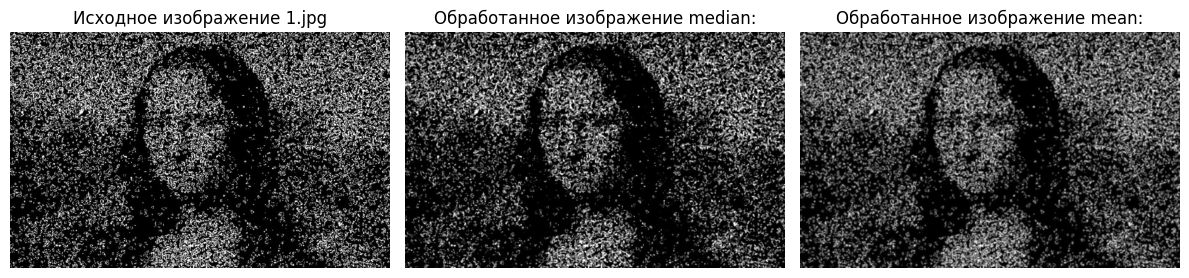

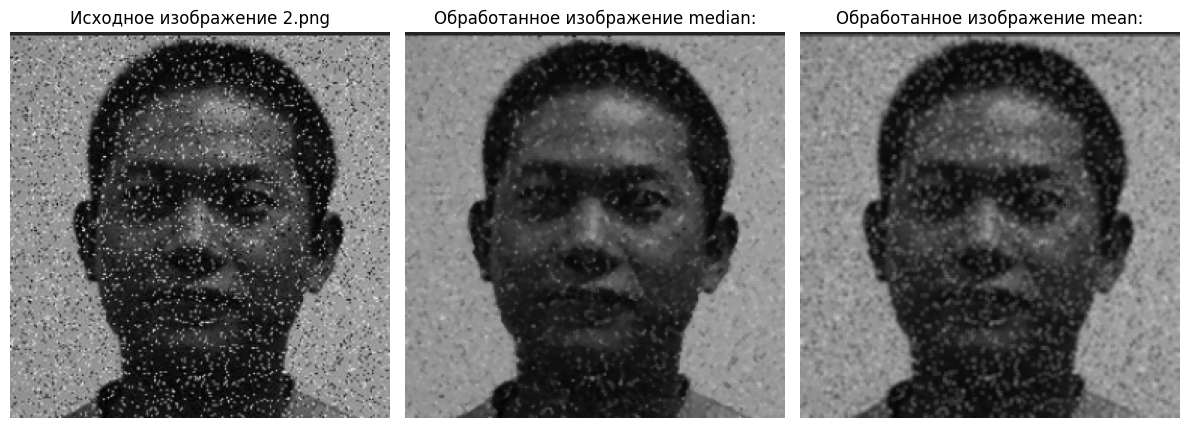

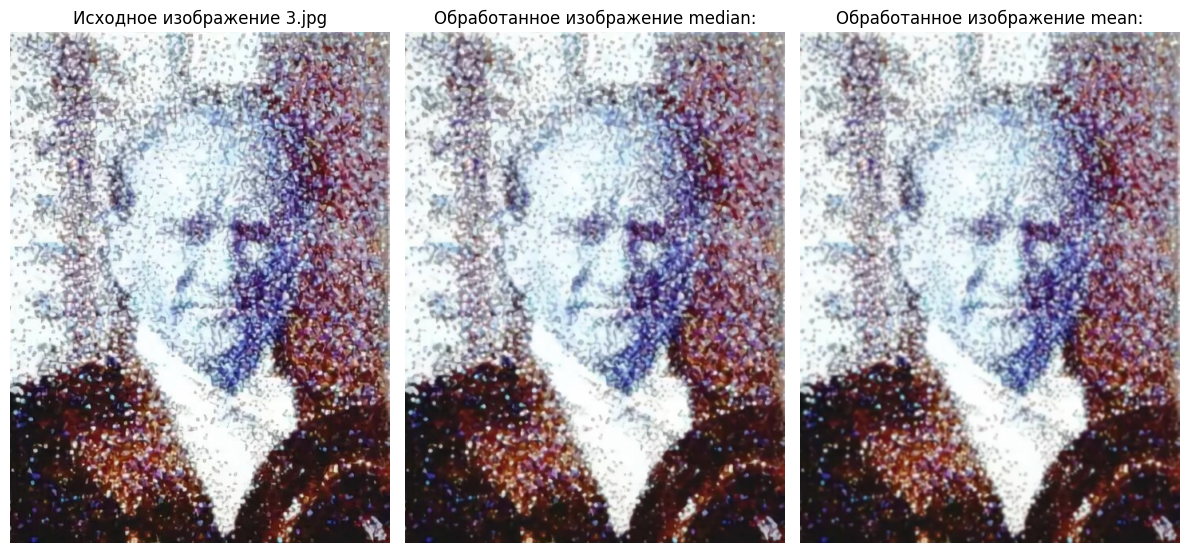

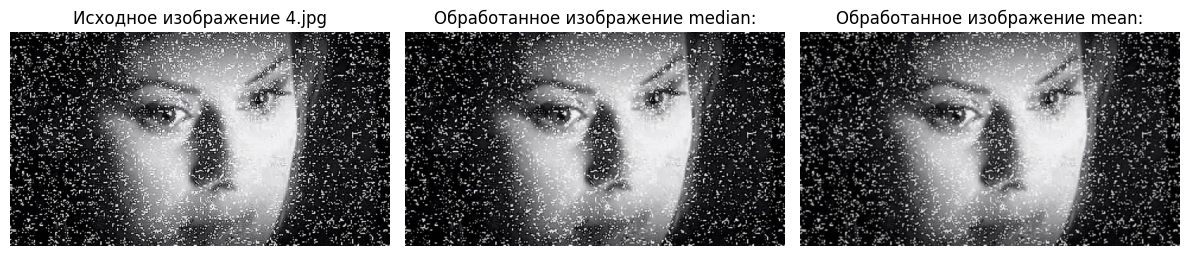

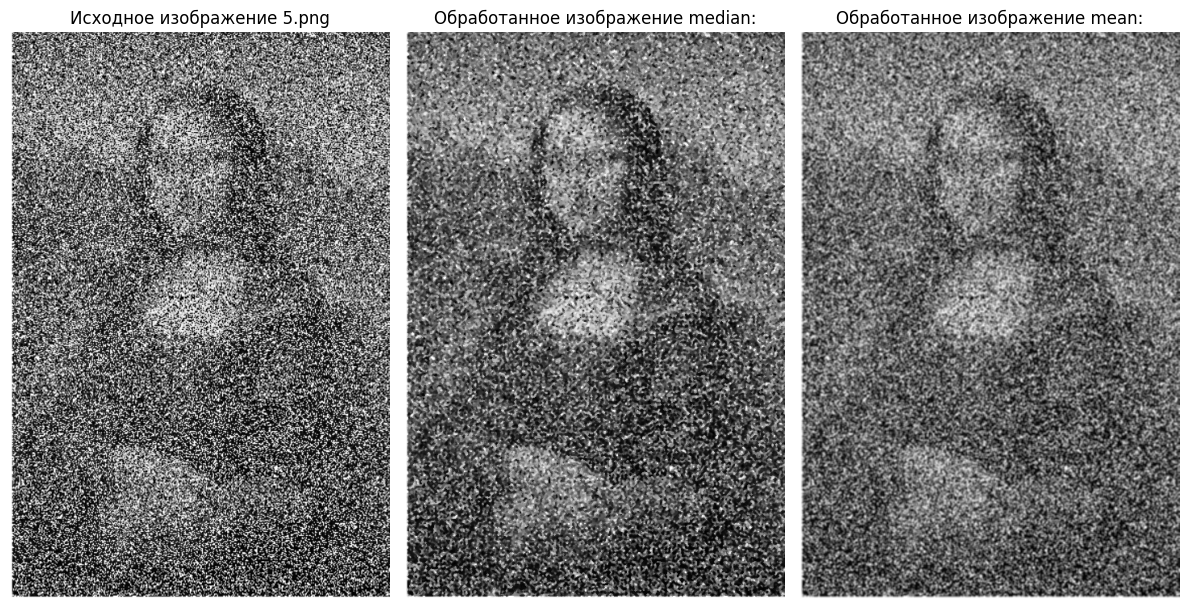

In [ ]:
images = ['1.jpg', '2.png', '3.jpg', '4.jpg', '5.png']

for img in images:
  filt(img)


### **Задание №2. Из подкаталога «Image_1» (каталога IMAGE), определить местонахождение всех фрагментов (Et_1.png - Et_10.png) на растре IMAGE.jpg, используя вышеописанный алгоритм. Вывести результаты в консоль по каждому эталону**

**Ссылка на Image_1: https://cloud.mail.ru/public/EA1a/sV96pAxaH**

In [ ]:
def func(image_path, fragment_path):
  # Загружаем исходное изображение
  image = cv2.imread(image_path)

  # Загружаем фрамент изображения (эталон)
  fragment = cv2.imread(fragment_path)

  # Проверяем, что изображения успешно загружены
  if image is None:
      print("Ошибка: не удалось загрузить исходное изображение.")
  if fragment is None:
      print("Ошибка: не удалось загрузить фрамент изображения.")

  # Получаем размеры фрамента
  (fragmentHeight, fragmentWidth) = fragment.shape[:2]

  # Осуществляем поиск фрамента на изображении
  result = cv2.matchTemplate(image, fragment, cv2.TM_CCOEFF)
  (_, _, minLoc, maxLoc) = cv2.minMaxLoc(result)

  # Выделяем искомый фрамент и отделяем его от изображения
  topLeft = maxLoc
  botRight = (topLeft[0] + fragmentWidth, topLeft[1] + fragmentHeight)
  roi = image[topLeft[1]:botRight[1], topLeft[0]:botRight[0]].copy()

  # Создаем затемненный прозрачный слой для затемнения всего изображения
  mask = np.zeros(image.shape, dtype="uint8")
  image_dark = cv2.addWeighted(image, 0.2, mask, 0.75, 0)

  # Возвращаем искомый фрамент в изображение
  image_dark[topLeft[1]:botRight[1], topLeft[0]:botRight[0]] = roi

  # Масштабируем изображение для отображения, если необходимо
  max_height = 950
  if image_dark.shape[0] > max_height:
      scale = max_height / image_dark.shape[0]
      image_display = cv2.resize(image_dark, None, fx=scale, fy=scale)
  else:
      image_display = image_dark

  # Отображаем результаты
  print("Исходное изображение с выделенным фраментом:")
  cv2_imshow(image_display)

  print("Фрамент изображения (эталон):")
  cv2_imshow(fragment)


In [ ]:
framgents_path = ['IMAGE/Et_1.png', 'IMAGE/Et_2.png', 'IMAGE/Et_3.png',
                  'IMAGE/Et_4.png', 'IMAGE/Et_5.png', 'IMAGE/Et_6.png',
                  'IMAGE/Et_7.png', 'IMAGE/Et_8.png', 'IMAGE/Et_9.png',
                  'IMAGE/Et_10.png']

image_path = 'IMAGE/IMAGE.jpg'

for framgent_path in framgents_path:
  func(image_path, framgent_path)

### **Задание №3. Создать свой эталон (фрагмент), а затем определить его местонахождение на растре (по образцу из примера выше).**

**Главное при создании фрагмента учесть его разрешение.**

Можно создать эталон на сайте: https://convert-my-image.com/CropImage_Ru или используя срезы NumPy.

Исходное изображение с выделенным фраментом:


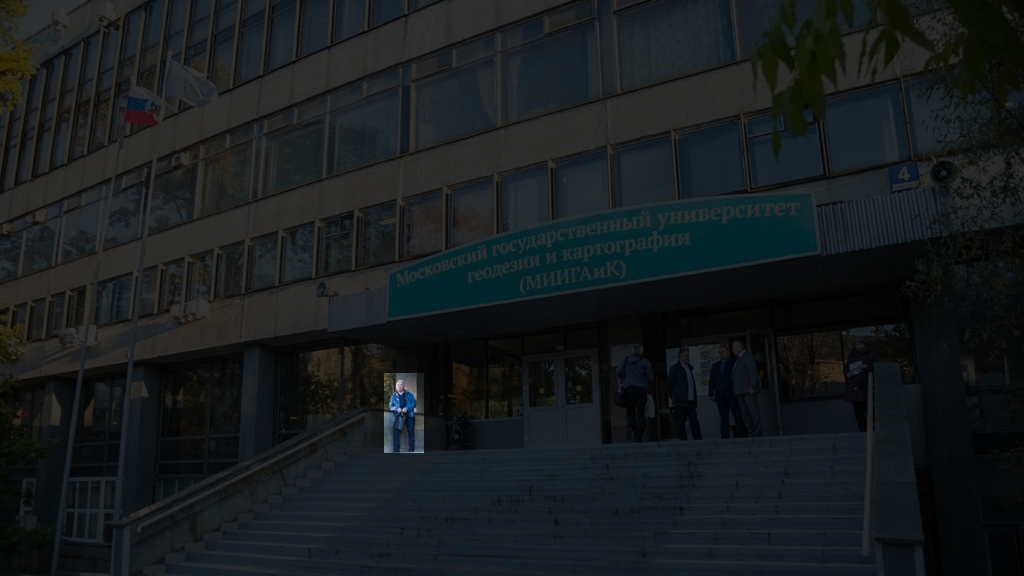

Фрамент изображения (эталон):


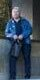

In [ ]:
fragment = 'myImage/fragment.jpg'
myImage = 'myImage/image.jpg'

func(myImage, fragment)